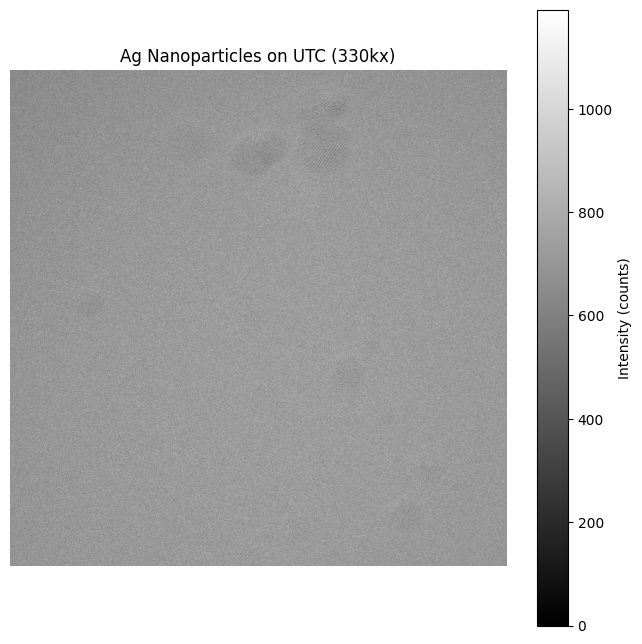

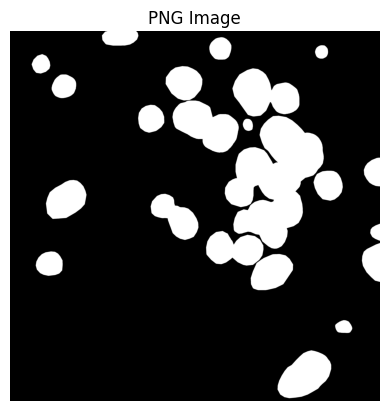

In [23]:
from ncempy.io import dm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3")
label_file = Path("../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/Labels/20220202_Ag_UTC_330kx_2650e_0p1596s_02_label.png")

# Load the DM3 file
data_dict = dm.dmReader(str(file.resolve()))

image_data = data_dict['data']
plt.figure(figsize=(8, 8))
plt.imshow(image_data, cmap='gray')
plt.title("Ag Nanoparticles on UTC (330kx)")
plt.colorbar(label='Intensity (counts)')
plt.axis('off') 
plt.show()


img = mpimg.imread(label_file)

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("PNG Image")
plt.show()

In [ ]:
from skimage.util import view_as_blocks

def split_patches(patch_size, image):
    blocks = view_as_blocks(image, block_shape=(patch_size, patch_size))
    patches = blocks.reshape(-1, patch_size, patch_size)

    return patches

In [6]:
patched_image = split_patches(16, image_data)

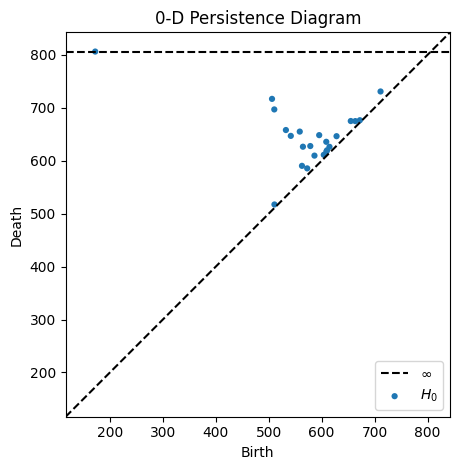

In [7]:
from persim import plot_diagrams
from ripser import lower_star_img

dgm = lower_star_img(patched_image[0])
plot_diagrams(dgm)
plt.title("0-D Persistence Diagram")
plt.tight_layout()
plt.show()


In [8]:
from scipy import ndimage
from persim import plot_diagrams
from ripser import lower_star_img
from persim import PersistenceImager
import numpy as np

pimgr = PersistenceImager(
    pixel_size=16,
    birth_range=(400, 700),
    pers_range=(0, 300)
)

def PH_patch(patched_image):
    dgms = []
    for p in patched_image:      
        dgm = lower_star_img(p)
        dgm = dgm[np.isfinite(dgm[:,1])]
        dgms.append(dgm)
    pimgr.fit(dgms)
    vectors = []
    for dgm in dgms:
        pimg = pimgr.transform(dgm)
        vec = pimg.ravel()
        vectors.append(vec)
    vectors = np.vstack(vectors)
    return vectors

vectorised_patches = PH_patch(patched_image)


In [86]:
print(vectorised_patches.shape)

(65536, 2242)


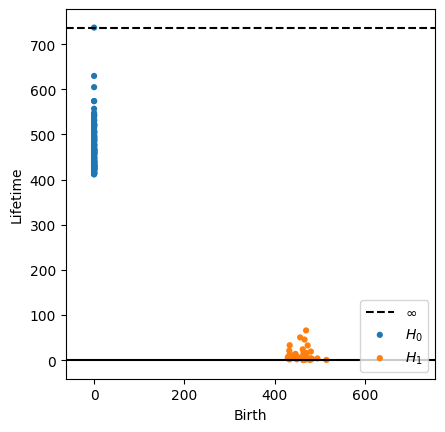

In [9]:
import ripser 

r = ripser.ripser(vectorised_patches, maxdim=1,n_perm=200)
dgms = r['dgms']
plot_diagrams(dgms, show=True, lifetime=True)

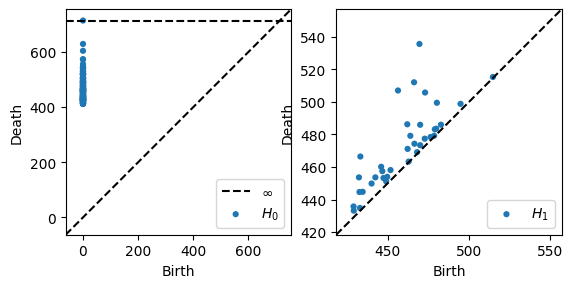

In [88]:
plot_diagrams(dgms, plot_only=[0], ax=plt.subplot(121))
plot_diagrams(dgms, plot_only=[1], ax=plt.subplot(122))

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_54798/3331302418.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


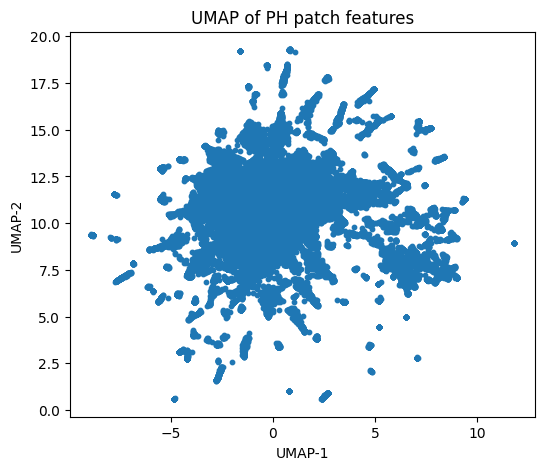

In [10]:
from sklearn.preprocessing import StandardScaler
import umap

X = StandardScaler().fit_transform(vectorised_patches)

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

embedding = reducer.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=10,
    cmap="Spectral"
)
plt.title("UMAP of PH patch features")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

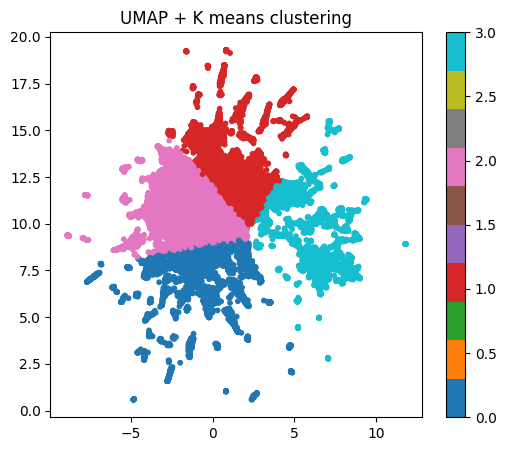

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(embedding)

plt.figure(figsize=(6,5))
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=labels,
    cmap="tab10",
    s=10
)
plt.title("UMAP + K means clustering")
plt.colorbar()
plt.show()

In [12]:
def get_positions(image_data):

    blocks = view_as_blocks(image_data, block_shape=(16, 16))
    n_rows, n_cols = blocks.shape[:2]

    positions = [
        (i * 16, j * 16)
        for i in range(n_rows)
        for j in range(n_cols)
    ]

    return positions

In [13]:
import numpy as np

def label_to_image(original_image, labels, positions):

    H, W = original_image.shape[:2]
    label_img = np.zeros((H, W), dtype=int)

    for (r, c), lab in zip(positions, labels):
        label_img[r:r+16, c:c+16] = lab

    return label_img

In [14]:
positions = get_positions(image_data)
label_img = label_to_image(image_data, labels, positions)

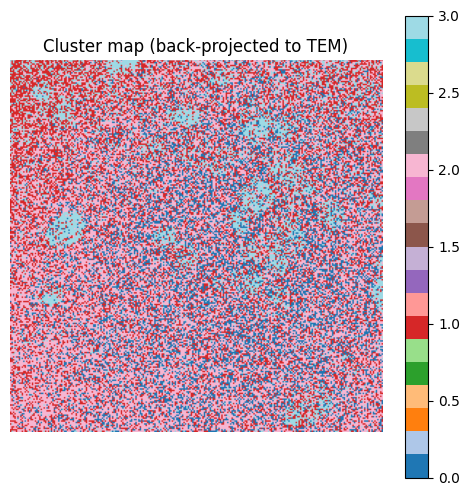

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

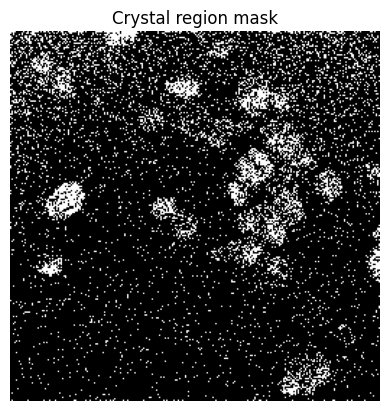

In [ ]:
target_cluster = 3  

mask = (label_img == target_cluster).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [17]:
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.morphology import binary_closing, disk

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_54798/3027865136.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


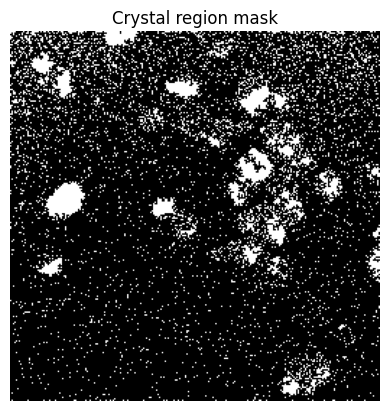

In [18]:
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

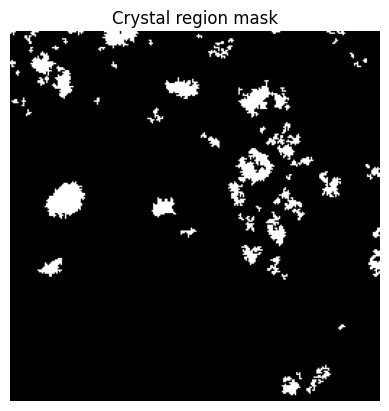

In [19]:
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

In [20]:
from skimage.metrics import adapted_rand_error

clean_img = clean_mask.astype(np.uint8)


are, precision, recall = adapted_rand_error(clean_img, label_image)

print("Adapted Rand Error:", are)
print("Precision:", precision)
print("Recall:", recall)

NameError: name 'label_image' is not defined

UMAP + GMM

In [115]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, covariance_type="full")
labels = gmm.fit_predict(embedding)

probs = gmm.predict_proba(embedding)

label_img = label_to_image(image_data, labels, positions)

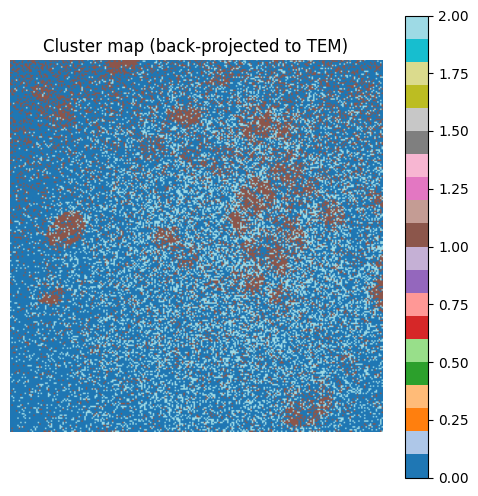

In [116]:
plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_43600/4275277384.py:7: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


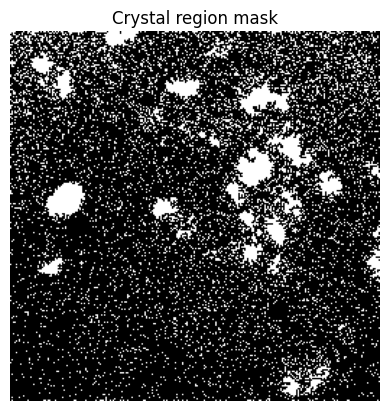

In [117]:
target_cluster = 1

mask = (label_img == target_cluster).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

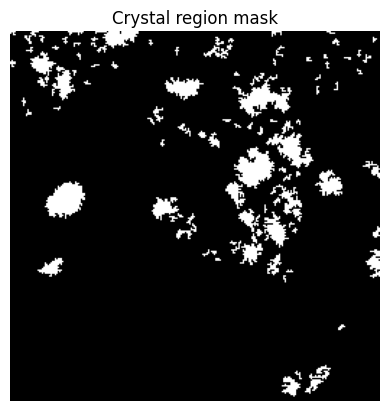

In [118]:
clean_mask = remove_small_objects(clean_mask, max_size=1600)
plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

UMAP + HDBSCAN

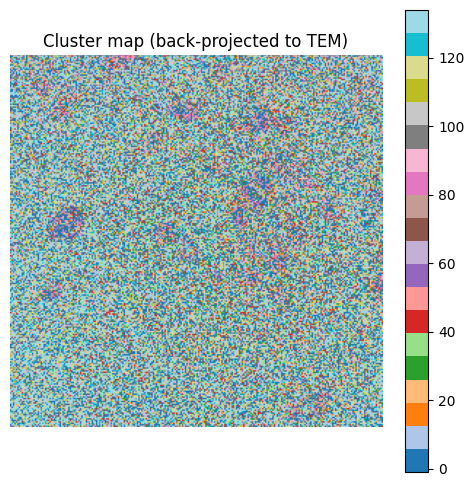

In [107]:
import hdbscan

labels = hdbscan.HDBSCAN(
    min_cluster_size=50
).fit_predict(embedding)

label_img = label_to_image(image_data, labels, positions)

plt.figure(figsize=(6,6))
plt.imshow(label_img, cmap="tab20")
plt.title("Cluster map (back-projected to TEM)")
plt.colorbar()
plt.axis("off")
plt.show()

In [109]:
unique, counts = np.unique(labels, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} points")

Cluster -1: 11655 points
Cluster 0: 165 points
Cluster 1: 84 points
Cluster 2: 116 points
Cluster 3: 161 points
Cluster 4: 235 points
Cluster 5: 51 points
Cluster 6: 126 points
Cluster 7: 475 points
Cluster 8: 232 points
Cluster 9: 62 points
Cluster 10: 108 points
Cluster 11: 96 points
Cluster 12: 121 points
Cluster 13: 59 points
Cluster 14: 397 points
Cluster 15: 130 points
Cluster 16: 96 points
Cluster 17: 90 points
Cluster 18: 161 points
Cluster 19: 68 points
Cluster 20: 82 points
Cluster 21: 84 points
Cluster 22: 86 points
Cluster 23: 72 points
Cluster 24: 133 points
Cluster 25: 485 points
Cluster 26: 365 points
Cluster 27: 596 points
Cluster 28: 203 points
Cluster 29: 59 points
Cluster 30: 147 points
Cluster 31: 52 points
Cluster 32: 53 points
Cluster 33: 622 points
Cluster 34: 891 points
Cluster 35: 123 points
Cluster 36: 110 points
Cluster 37: 166 points
Cluster 38: 94 points
Cluster 39: 1092 points
Cluster 40: 55 points
Cluster 41: 135 points
Cluster 42: 128 points
Cluster 43: 

/home/eng-6770/Documents/TEM_Exploration/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:386: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  return func(*args, **kwargs)
/tmp/ipykernel_43600/2152952435.py:5: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  clean = binary_closing(clean_mask, footprint=disk(2))


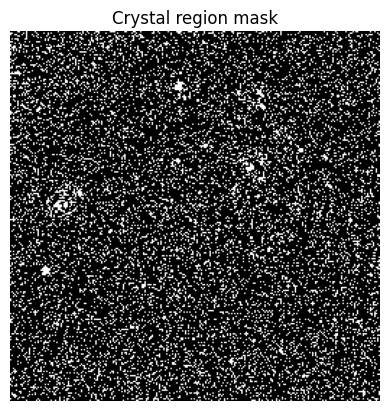

In [114]:


mask = ((label_img == -1) | (label_img == 90)).astype(np.uint8)

clean_mask = remove_small_objects(mask, max_size=100)
clean_mask = binary_fill_holes(clean_mask)
clean = binary_closing(clean_mask, footprint=disk(2))

plt.imshow(clean_mask, cmap="gray")
plt.title("Crystal region mask")
plt.axis("off")
plt.show()

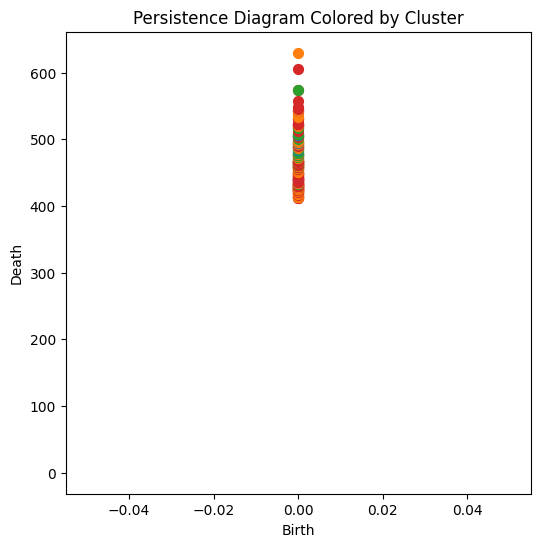

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams

points = vectorised_patches
cluster_labels = labels         

diagrams = ripser(vectorised_patches, maxdim=1,n_perm=200)['dgms']

plt.figure(figsize=(6,6))
colors = plt.cm.tab10(cluster_labels % 10)  

h0 = diagrams[0]

for idx, (b,d) in enumerate(h0):
    plt.scatter(b, d, color=colors[idx], s=50)

plt.plot([0, max(h0[:,1])], [0, max(h0[:,1])], 'k--')  # diagonal
plt.xlabel("Birth")
plt.ylabel("Death")
plt.title("Persistence Diagram Colored by Cluster")
plt.show()

In [25]:
import numpy as np

cluster_ids = np.unique(labels)
cluster_avgs = {}

for c in cluster_ids:
    cluster_avgs[c] = vectorised_patches[labels == c].mean(axis=0)

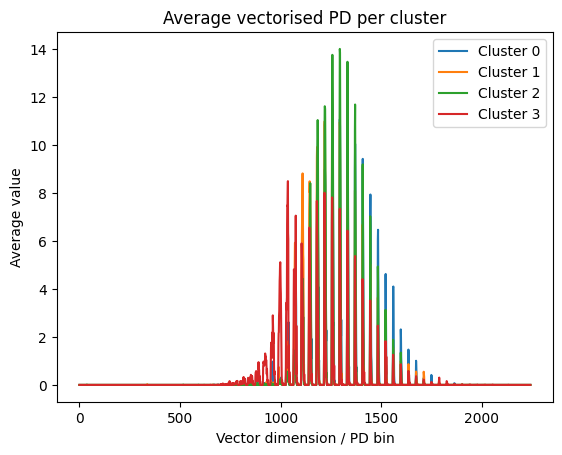

In [26]:
import matplotlib.pyplot as plt

for c in cluster_ids:
    plt.plot(cluster_avgs[c], label=f"Cluster {c}")

plt.xlabel("Vector dimension / PD bin")
plt.ylabel("Average value")
plt.title("Average vectorised PD per cluster")
plt.legend()
plt.show()